In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

In [4]:
df = pd.read_csv("dataset.xls")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,smoking,diabetes,bmi,heart_disease
0,67,1,2,111,536,0,2,88,0,1.3,3,2,3,1,0,23.4,1
1,57,1,3,109,107,0,2,119,0,5.4,2,0,3,0,1,35.4,0
2,43,1,4,171,508,0,1,113,0,3.7,3,0,7,1,1,29.9,0
3,71,0,4,90,523,0,2,152,0,4.7,2,1,3,1,0,15.2,1
4,36,1,2,119,131,0,2,128,0,5.9,3,1,3,1,0,16.7,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3064,52,0,1,169,479,0,0,124,0,3.7,2,3,3,0,0,27.8,0
3065,75,0,4,90,372,0,2,141,0,2.1,2,2,3,0,1,37.0,1
3066,68,1,4,166,564,0,1,76,0,4.5,3,1,3,0,0,16.1,1
3067,66,0,3,143,113,1,1,207,0,3.6,1,0,6,0,0,27.7,0


In [5]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,smoking,diabetes,bmi,heart_disease
0,67,1,2,111,536,0,2,88,0,1.3,3,2,3,1,0,23.4,1
1,57,1,3,109,107,0,2,119,0,5.4,2,0,3,0,1,35.4,0
2,43,1,4,171,508,0,1,113,0,3.7,3,0,7,1,1,29.9,0
3,71,0,4,90,523,0,2,152,0,4.7,2,1,3,1,0,15.2,1
4,36,1,2,119,131,0,2,128,0,5.9,3,1,3,1,0,16.7,1


In [6]:
print("Shape of dataset:", df.shape)

Shape of dataset: (3069, 17)


In [7]:
print("Columns:")
print(df.columns)

Columns:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'smoking', 'diabetes', 'bmi',
       'heart_disease'],
      dtype='object')


In [8]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,smoking,diabetes,bmi,heart_disease
count,3069.00000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000
mean,52.50114,0.555556,2.489736,145.306289,347.219941,0.145650,1.004236,135.157380,0.176279,3.189052,2.023786,0.626588,4.544477,0.348974,0.193874,27.496839,0.388074
std,13.70752,0.496985,1.110417,31.602321,146.853319,0.352813,0.812016,43.353197,0.381119,1.802815,0.817679,0.891447,1.751064,0.476723,0.395396,7.281731,0.487391
min,29.00000,0.000000,1.000000,90.000000,100.000000,0.000000,0.000000,60.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000,15.000000,0.000000
25%,41.00000,0.000000,2.000000,118.000000,215.000000,0.000000,0.000000,98.000000,0.000000,1.600000,1.000000,0.000000,3.000000,0.000000,0.000000,21.300000,0.000000
50%,53.00000,1.000000,2.000000,146.000000,350.000000,0.000000,1.000000,135.000000,0.000000,3.200000,2.000000,0.000000,3.000000,0.000000,0.000000,27.400000,0.000000
75%,64.00000,1.000000,3.000000,172.000000,475.000000,0.000000,2.000000,172.000000,0.000000,4.700000,3.000000,1.000000,6.000000,1.000000,0.000000,33.900000,1.000000
max,76.00000,1.000000,4.000000,200.000000,600.000000,1.000000,2.000000,210.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000,1.000000,40.000000,1.000000


In [9]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
age              0
sex              0
cp               0
trestbps         0
chol             0
fbs              0
restecg          0
thalach          0
exang            0
oldpeak          0
slope            0
ca               0
thal             0
smoking          0
diabetes         0
bmi              0
heart_disease    0
dtype: int64


In [10]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


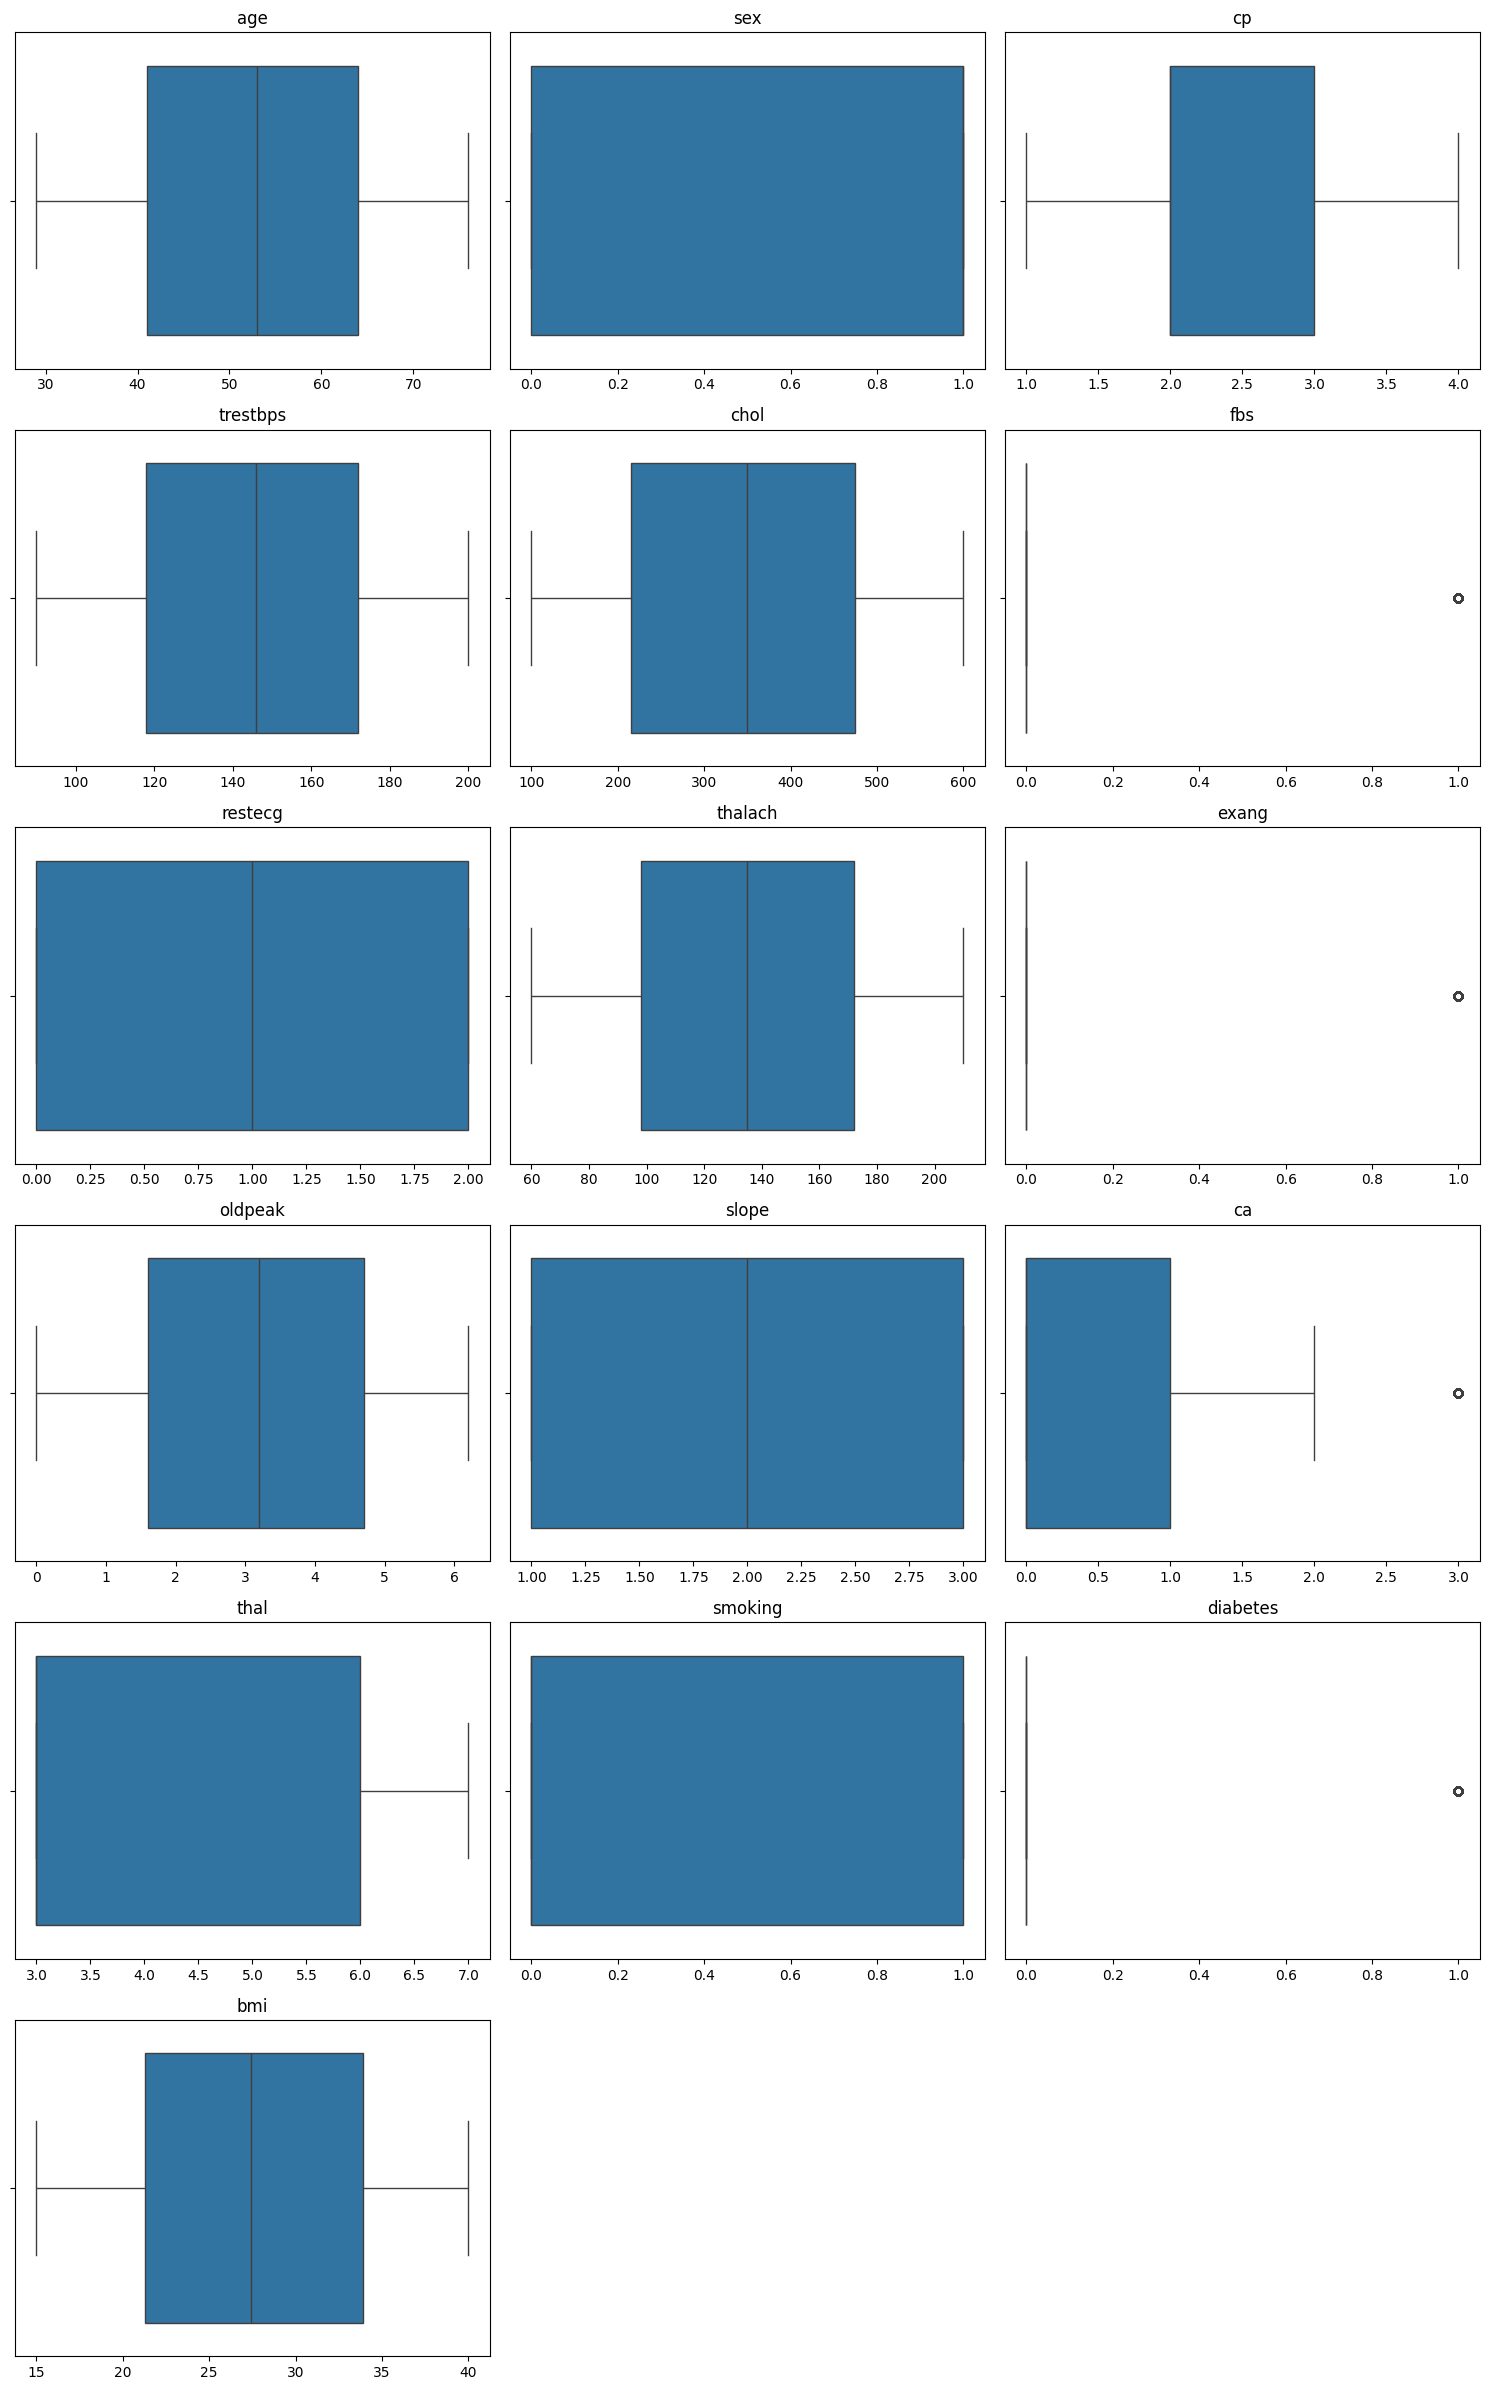

In [17]:
num_cols = [col for col in df.select_dtypes(include=["int64", "float64"]).columns 
            if col != "heart_disease"]

rows = (len(num_cols) + 2) // 3   # 3 plots per row

fig, axes = plt.subplots(rows, 3, figsize=(15, rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("")

# Remove extra empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [18]:
num_cols = [col for col in df.select_dtypes(include=["int64", "float64"]).columns 
            if col != "heart_disease"]

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print("Shape after outlier removal:", df.shape)

Shape after outlier removal: (1661, 17)


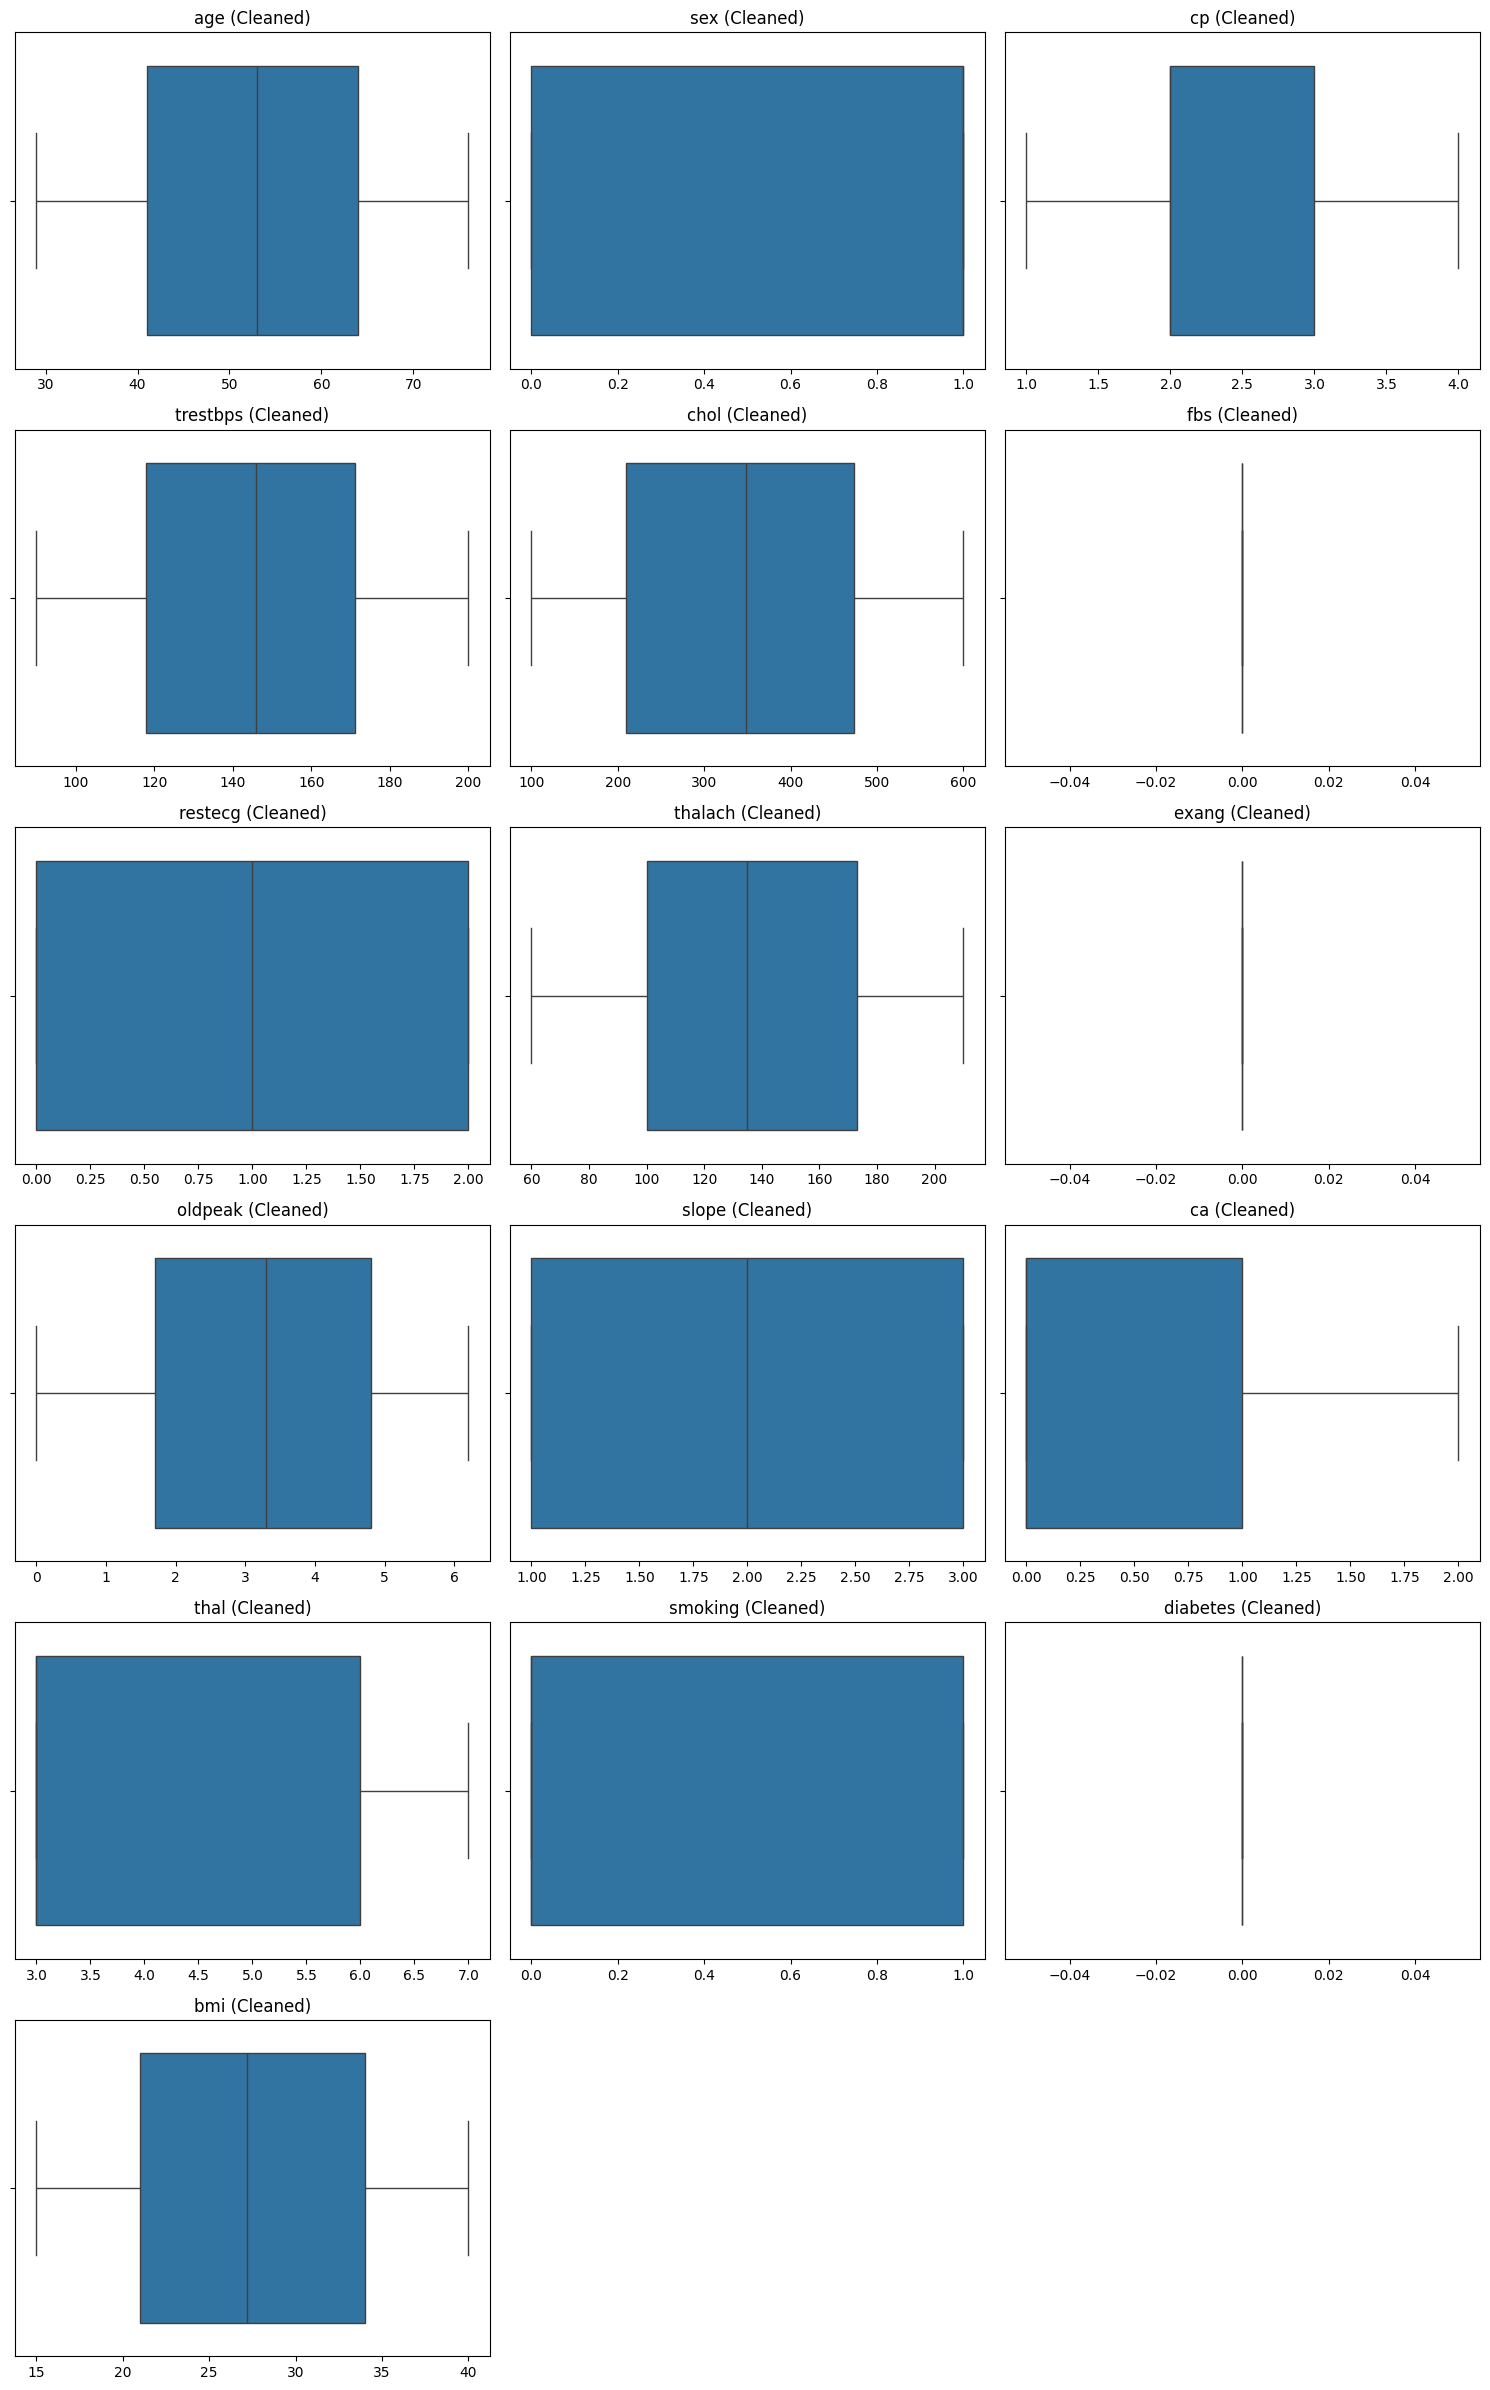

In [19]:
num_cols = [col for col in df.select_dtypes(include=["int64", "float64"]).columns 
            if col != "heart_disease"]

rows = (len(num_cols) + 2) // 3

fig, axes = plt.subplots(rows, 3, figsize=(15, rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"{col} (Cleaned)")
    axes[i].set_xlabel("")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [11]:
target = "heart_disease"

features = [col for col in df.columns if col != target]

X = df[features]
y = df[target]

print("Selected Features:")
print(features)

print("\nTarget Column:")
print(target)

Selected Features:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'smoking', 'diabetes', 'bmi']

Target Column:
heart_disease


In [13]:
corr_with_target = df.corr()["heart_disease"].sort_values(ascending=False)

print(corr_with_target)

heart_disease    1.000000
age              0.286731
chol             0.015789
restecg          0.012317
thalach          0.007567
fbs              0.006693
cp              -0.000166
sex             -0.000897
trestbps        -0.002260
bmi             -0.005477
diabetes        -0.006603
slope           -0.009266
thal            -0.010874
ca              -0.012953
oldpeak         -0.014341
smoking         -0.014909
exang           -0.033249
Name: heart_disease, dtype: float64


In [24]:
fin_features = ['age', 'chol', 'restecg', 'thalach']
target = 'heart_disease'

X = df[fin_features]
y = df[target]

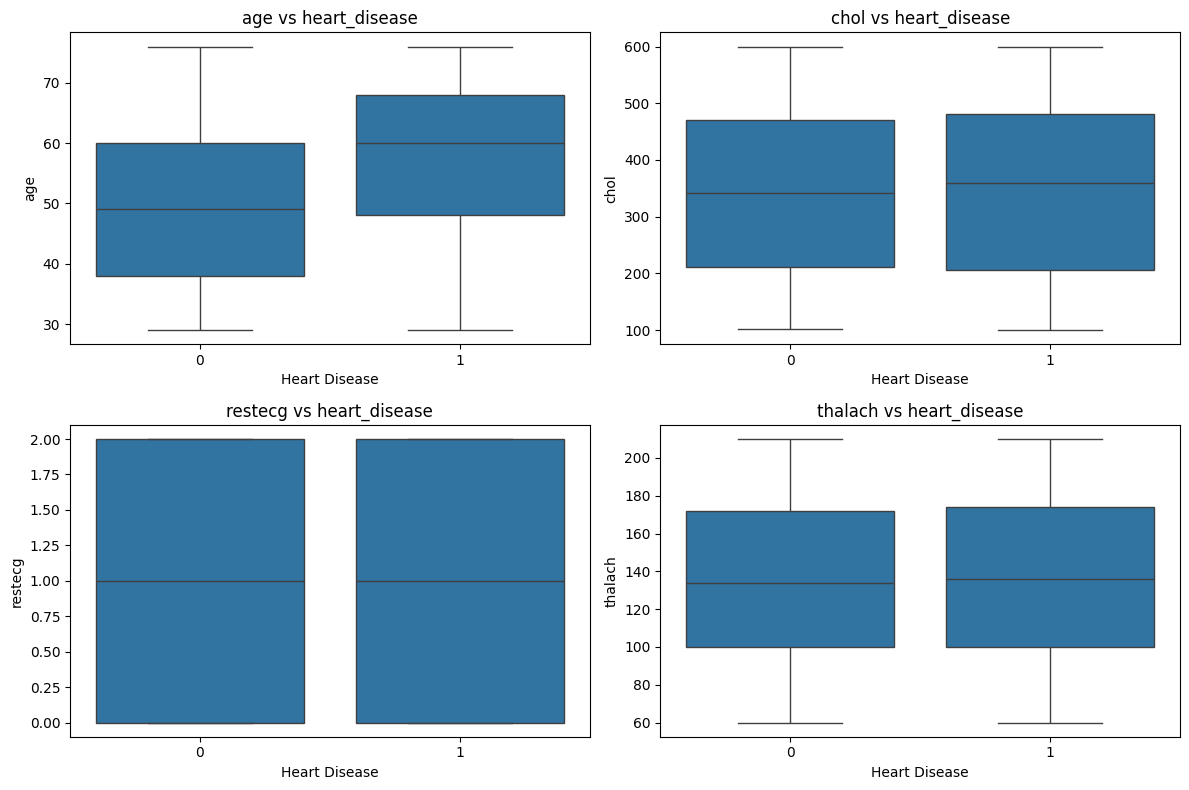

In [25]:
rows = (len(fin_features) + 1) // 2

fig, axes = plt.subplots(rows, 2, figsize=(12, rows * 4))
axes = axes.flatten()

for i, col in enumerate(fin_features):
    sns.boxplot(x=df[target], y=df[col], ax=axes[i])
    axes[i].set_title(f"{col} vs {target}")
    axes[i].set_xlabel("Heart Disease")
    axes[i].set_ylabel(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

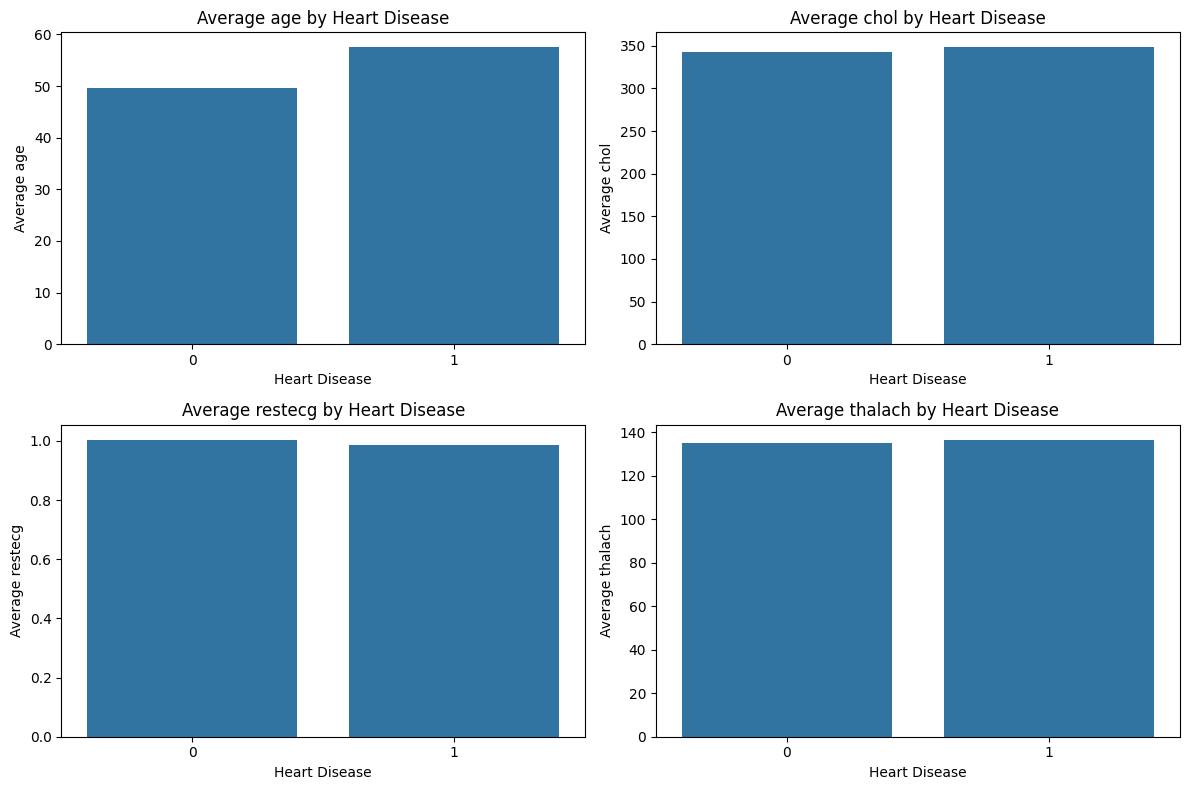

In [26]:
fig, axes = plt.subplots(rows, 2, figsize=(12, rows * 4))
axes = axes.flatten()

for i, col in enumerate(fin_features):
    sns.barplot(x=df[target], y=df[col], ax=axes[i], errorbar=None)
    axes[i].set_title(f"Average {col} by Heart Disease")
    axes[i].set_xlabel("Heart Disease")
    axes[i].set_ylabel(f"Average {col}")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

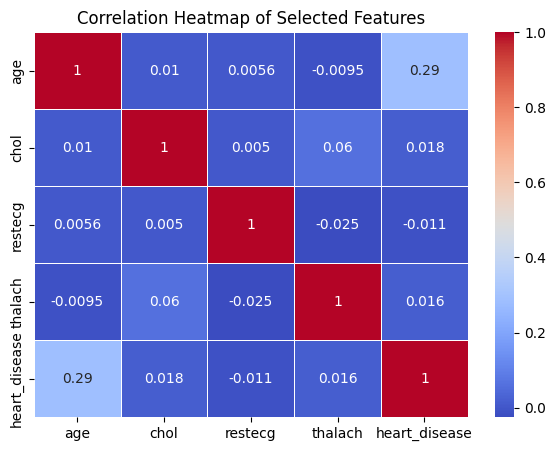

In [28]:
plt.figure(figsize=(7, 5))
sns.heatmap(
    df[fin_features + [target]].corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Selected Features")
plt.show()

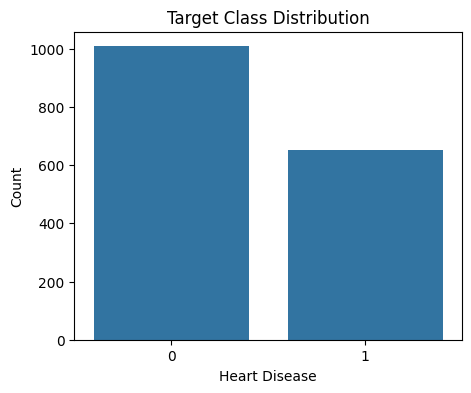

In [29]:
plt.figure(figsize=(5,4))
sns.countplot(x=df[target])
plt.title("Target Class Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

In [32]:
final_df = df[fin_features + [target]]

final_df.to_csv("final_data.csv", index=False)

print("EDA Processed Data Saved...")

EDA Processed Data Saved...
